In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PARAMETERS
# ============================================================

num_episodes = 25_000

gamma = 0.99

# This is the "overall" learning-rate parameter.
# Since num_tilings features are active at once,
# we divide it by num_tilings during each update.
alpha = 0.5

epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.00025

num_tilings = 8
tiles_per_dim = 8

seed = 42

rng = np.random.default_rng(seed)


# ============================================================
# ENVIRONMENT
# ============================================================

env = gym.make("MountainCar-v0")

state_low = env.observation_space.low
state_high = env.observation_space.high

num_actions = env.action_space.n

print("State low:", state_low)
print("State high:", state_high)
print("Number of actions:", num_actions)

State low: [-1.2  -0.07]
State high: [0.6  0.07]
Number of actions: 3


In [2]:
# ============================================================
# TILE CODING
# ============================================================

num_features_per_tiling = tiles_per_dim * tiles_per_dim

num_features = num_tilings * num_features_per_tiling


def get_active_features(state):
    """
    Return the indices of the active tile features for a
    continuous MountainCar state.

    Exactly one feature is active in each tiling.
    """

    position, velocity = state

    active_features = []

    # Width of one tile in physical state coordinates
    tile_width_position = (
        state_high[0] - state_low[0]
    ) / tiles_per_dim

    tile_width_velocity = (
        state_high[1] - state_low[1]
    ) / tiles_per_dim

    for tiling in range(num_tilings):

        # Different offsets for the two dimensions
        offset_fraction_position = tiling / num_tilings

        offset_fraction_velocity = (
            (2 * tiling + 1) % num_tilings
        ) / num_tilings

        offset_position = (
            offset_fraction_position
            * tile_width_position
        )

        offset_velocity = (
            offset_fraction_velocity
            * tile_width_velocity
        )

        # Determine tile coordinates in this tiling
        position_index = int(
            np.floor(
                (
                    position
                    - state_low[0]
                    + offset_position
                )
                / tile_width_position
            )
        )

        velocity_index = int(
            np.floor(
                (
                    velocity
                    - state_low[1]
                    + offset_velocity
                )
                / tile_width_velocity
            )
        )

        # Keep indices inside the grid
        position_index = np.clip(
            position_index,
            0,
            tiles_per_dim - 1
        )

        velocity_index = np.clip(
            velocity_index,
            0,
            tiles_per_dim - 1
        )

        # Convert the 2D tile coordinate into one local index
        local_index = (
            position_index * tiles_per_dim
            + velocity_index
        )

        # Each tiling owns a different part of the feature vector
        global_index = (
            tiling * num_features_per_tiling
            + local_index
        )

        active_features.append(global_index)

    return np.array(active_features, dtype=int)

In [3]:
# ============================================================
# LINEAR FUNCTION APPROXIMATOR
# ============================================================

weights = np.zeros(
    (num_actions, num_features)
)

In [4]:
def q_values(state, action):
    active = get_active_features(state)

    return np.sum(
        weights[action, active]
    )

In [5]:
def choose_action(state, epsilon):

    if rng.random() < epsilon:
        return rng.integers(num_actions)

    values = q_values(state, action)

    max_actions = np.flatnonzero(
        values == np.max(values)
    )

    return rng.choice(max_actions)

In [6]:
def update_weights(
    state,
    action,
    reward,
    next_state,
    terminated
):

    active = get_active_features(state)

    current_q = np.sum(
        weights[action, active]
    )

    if terminated:

        target = reward

    else:

        next_q = q_values(next_state, action)

        target = (
            reward
            + gamma * np.max(next_q)
        )

    td_error = target - current_q

    # Because 8 features are simultaneously active,
    # scale the step size accordingly.
    effective_alpha = alpha / num_tilings

    weights[action, active] += (
        effective_alpha * td_error
    )

    return td_error

In [13]:
# ============================================================
# TRAINING
# ============================================================

episode_lengths = []
episode_successes = []
td_errors = []


for episode in range(num_episodes):

    state, info = env.reset()

    epsilon = (
        epsilon_min
        +
        (epsilon_start - epsilon_min)
        * np.exp(-epsilon_decay * episode)
    )

    terminated = False
    truncated = False

    steps = 0

    while not (terminated or truncated):

        action = choose_action(
            state,
            epsilon
        )

        (
            next_state,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(action)

        td_error = update_weights(
            state,
            action,
            reward,
            next_state,
            terminated
        )

        td_errors.append(abs(td_error))

        state = next_state

        steps += 1

    episode_lengths.append(steps)

    success = int(terminated)

    episode_successes.append(success)

    if (episode + 1) % 1000 == 0:

        recent_success_rate = np.mean(
            episode_successes[-1000:]
        )

        recent_length = np.mean(
            episode_lengths[-1000:]
        )

        print(
            f"Episode {episode + 1:5d} | "
            f"epsilon = {epsilon:.3f} | "
            f"success = {recent_success_rate:.3f} | "
            f"length = {recent_length:.1f}"
        )

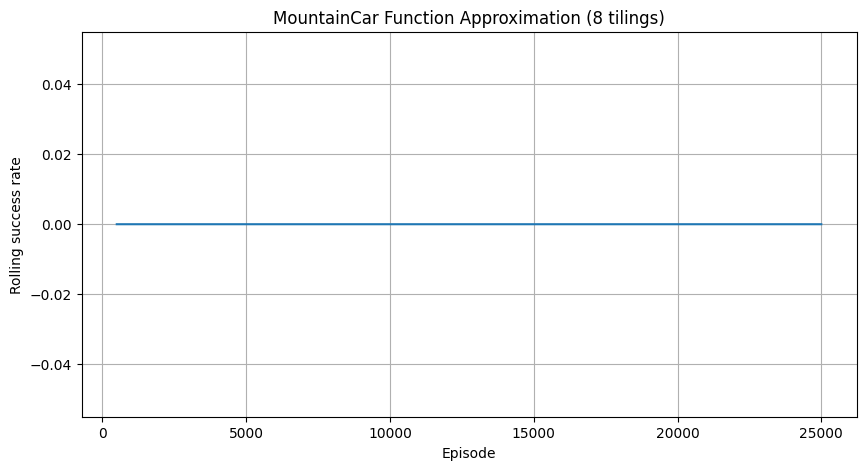

In [8]:
rolling_window = 500

success_array = np.array(
    episode_successes,
    dtype=float
)

kernel = np.ones(rolling_window) / rolling_window

rolling_success = np.convolve(
    success_array,
    kernel,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(
        rolling_window - 1,
        num_episodes
    ),
    rolling_success
)

plt.xlabel("Episode")
plt.ylabel("Rolling success rate")
plt.title(
    f"MountainCar Function Approximation "
    f"({num_tilings} tilings)"
)

plt.grid()

plt.show()

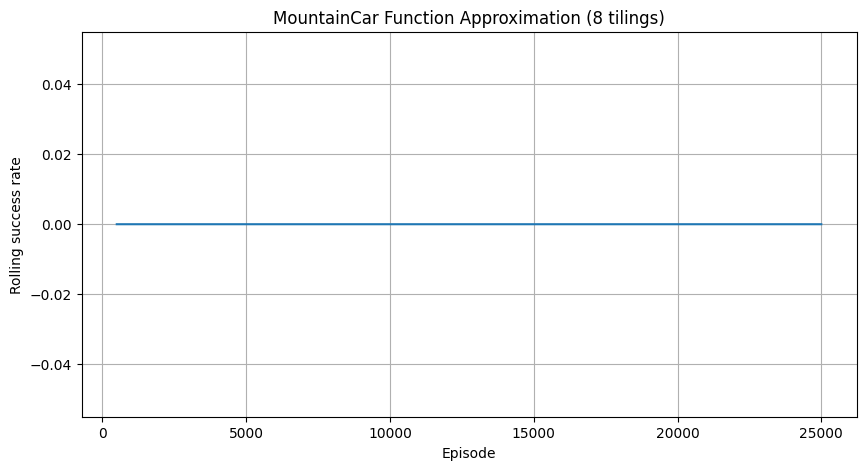

In [9]:
rolling_window = 500

success_array = np.array(
    episode_successes,
    dtype=float
)

kernel = np.ones(rolling_window) / rolling_window

rolling_success = np.convolve(
    success_array,
    kernel,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(
        rolling_window - 1,
        num_episodes
    ),
    rolling_success
)

plt.xlabel("Episode")
plt.ylabel("Rolling success rate")
plt.title(
    f"MountainCar Function Approximation "
    f"({num_tilings} tilings)"
)

plt.grid()

plt.show()

In [11]:
# ============================================================
# TESTING
# ============================================================

num_test_episodes = 1000

test_successes = 0
test_episode_lengths = []


for episode in range(num_test_episodes):

    state, info = env.reset()

    terminated = False
    truncated = False

    steps = 0

    while not (terminated or truncated):

        values = q_values(state, action)

        max_actions = np.flatnonzero(
            values == np.max(values)
        )

        action = rng.choice(max_actions)

        (
            next_state,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(action)

        state = next_state
        steps += 1

    test_successes += int(terminated)

    test_episode_lengths.append(steps)


print(
    "Test success rate:",
    test_successes / num_test_episodes
)

print(
    "Average test episode length:",
    np.mean(test_episode_lengths)
)

Test success rate: 0.0
Average test episode length: 200.0
